# 预处理

In [1]:
!whoami

root


In [2]:
!pwd

/mnt/workspace


In [3]:
import os
from tensorflow.keras.datasets import imdb

# ===========================
# 注释：Keras imdb评论数据集加载
# ===========================
# Keras会自动下载IMDB数据集，默认目录：
# Windows: C:\Users\<你的用户名>\.keras\datasets
# Mac:    /Users/<你的用户名>/.keras/datasets/
# Linux:  /home/<用户名>/.keras/datasets/
# 数据文件较大，如在服务器，可提前放入本地缓存目录用于加速。

# ================================
# 设定只考虑高频前1万个词，减少计算量
# index_from=3的含义：
#   原词典索引从1开始，但加载后Keras会为 0,1,2 预留特殊用途（详见下方）
#   所以我们自定义词表时也要偏移3
# ================================
num_words = 10000  # 只用最常见的10000个单词
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words, index_from=3)
# x_train, x_test: 一维list，每个元素是包含若干词语编号(int)的list
# y_train, y_test: 影评的情感标签(0/1), 0为负面，1为正面

print(type(x_train))       # <class 'numpy.ndarray'>
print(x_train.shape)       # 训练集样本数量, 例如 (25000,)
print(x_test.shape)        # 测试集样本数量

# 查看第一个样本的编码表示
print("第一个训练样本：", x_train[0])   # 输出：首个训练评论的编号序列
print("标签：", y_train[0:10])         # 输出：前10条标签

# ===============================
# 加载 imdb 单词->索引 的原始映射（Keras自带的是单词:索引，索引从1开始）
# ===============================
word_index = imdb.get_word_index()      # dict: word -> index（原始，未做偏移）

# ===============================
# 我们使用的词表，需要将所有原始index统一+3，
# 因为要把 0,1,2,3 用作特殊符号
#   0: 填充符(PAD)
#   1: 句子开始符(BOS)
#   2: 未知词符(UNK)
#   3: 句子结束符(EOS)
# ===============================
word_index = {word: idx + 3 for word, idx in word_index.items()}  # 所有index偏移+3
word_index.update({
    "[PAD]": 0,  # 填充 token（补齐到一致长度）
    "[BOS]": 1,  # 句子起始符号
    "[UNK]": 2,  # 未知 token（语料中没见过的词）
    "[EOS]": 3,  # 句子结束符号
})

# 样本中的句子开头结尾的符号（如BOS/EOS）并不是Keras imdb原始数据自带的——
# Keras的imdb数据加载器自动为词典预留0/1/2三个索引：
#   0: padding
#   1: start of sequence (BOS)
#   2: unknown (UNK)
# 但实际上，imdb.load_data加载出来的样本序列里，默认只有“1”作为句子开始符号在每个样本首位，
# 没有结束符号（EOS）。即，开头的“1”由Keras加载器自动加到每个样本头部，
# 而结尾没有自动加[EOS]，需要用户自己补充。

# 预留012是谁的行为？原始Keras imdb数据加载器！
# Keras imdb词典加载出来，index_from参数就是用来决定index的偏移量（默认预留0/1/2）。
# 也就是说：
#   - Keras最初的词典index是1开始（即索引1~n被分配给常用词），
#   - 然后Keras预留出0/1/2，分别用于PAD, BOS, UNK

# 预留0123是谁的行为？我们自己的行为！
#   - 为了同时支持[EOS]（通常用在NLP任务pad到句末），本代码在上述基础上再预留了3（[EOS]）。
#   - 所以最终我们把Keras原始词表的所有index统一+3，腾挪出0([PAD]), 1([BOS]), 2([UNK]), 3([EOS])四个特殊符号用。

# 总结：
#   - “预留0,1,2”是Keras imdb自带的数据加载处理（0:PAD, 1:BOS, 2:UNK）
#   - “预留0,1,2,3”则是我们在加载词表时为自定义特殊符号腾出的空间（再加3: [EOS]）
#   - 样本的开头的“1”是imdb.load_data自动在每条评论第一位加的，结尾的[EOS](3)仅在我们手动加时才有。

# 其实这两者并不矛盾。Keras imdb原始词典的确是从1开始编号的（比如 "the": 1, "and": 2 ...）。
# 但在用`imdb.load_data()`读数据的时候，Keras会把词的索引整体做一次偏移（通过`index_from`参数，默认是3），
# 为了给特殊符号（PAD, BOS, UNK）预留空间。这么做的逻辑流程如下：
#
# 1. imdb.get_word_index() 得到原始单词到索引的映射（从1开始）。
#    例：{'the': 1, 'and': 2, ...}
# 2. imdb.load_data() 在加载数据时，会把训练集/测试集中的所有单词索引全部+index_from (默认是3)。
#    并且会：
#      - 在每条评论最前面加一个1，表示BOS（句子开始符号）
#      - 数据中的0始终做padding用（不足时补0，或补齐到同一长度）
#      - 词表之外的单词用2（UNK）表示。
#
# 也就是说：
#   - 词典里是1, 2, 3...（原始），但真正用在训练集上的编号是：4, 5, 6...（统一+3），
#     0专门做padding, 1是BOS, 2是UNK。实际数据集里，0/1/2都有特殊含义，单词部分编号就从3开始了。
#
# 总结一句：原始映射从1开始，数据集又预留了0/1/2/（我们再加了3），实际上单词mapping就自动向后顺延了。


# 打印第2个样本（编号序列）
print(x_train[-1])


2026-01-23 00:23:58.629438: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 00:23:59.487108: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 00:24:01.530515: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


<class 'numpy.ndarray'>
(25000,)
(25000,)
第一个训练样本： [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
标签： [1 0 

In [4]:
word_index['the']

4

In [5]:
# 构建索引到词的词典
index_to_word = {idx: word for word, idx in word_index.items()}

# 编写decode_review函数
def decode_review(encoded_review):
    return ' '.join([index_to_word.get(idx, '?') for idx in encoded_review])

# 测试decode_review函数，查看第一个训练样本原始文本内容
print("解码后的第一个训练样本：")
print(decode_review(x_train[0]))


解码后的第一个训练样本：
[BOS] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and now the same being director [UNK] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [UNK] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [UNK] to the two little boy's that played the [UNK] of norman and paul they were just brilliant children are often left out of the [UNK] list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be prai

In [6]:
index_to_word[1]

'[BOS]'

In [7]:
import numpy as np

#如何将ndarray存入磁盘及读取
# 将训练和测试数据保存到磁盘
# np.save('x_train.npy', x_train, allow_pickle=True)
# np.save('y_train.npy', y_train, allow_pickle=True)
# np.save('x_test.npy', x_test, allow_pickle=True)
# np.save('y_test.npy', y_test, allow_pickle=True)

# # 从磁盘读取保存的数据
# x_train_loaded = np.load('x_train.npy', allow_pickle=True)
# y_train_loaded = np.load('y_train.npy', allow_pickle=True)
# x_test_loaded = np.load('x_test.npy', allow_pickle=True)
# y_test_loaded = np.load('y_test.npy', allow_pickle=True)

# print('x_train_loaded shape:', x_train_loaded.shape)
# print('y_train_loaded shape:', y_train_loaded.shape)
# print('x_test_loaded shape:', x_test_loaded.shape)
# print('y_test_loaded shape:', y_test_loaded.shape)


In [8]:
# 将测试集划分为验证集和测试集
# 从原始测试集中取前10000个样本作为验证集
x_val = x_test[:10000]
y_val = y_test[:10000]

# 剩余的15000个样本作为测试集
x_test = x_test[10000:]
y_test = y_test[10000:]

print(f"验证集样本数: {len(x_val)}")
print(f"测试集样本数: {len(x_test)}")
print(f"验证集标签示例: {y_val[:10]}")
print(f"测试集标签示例: {y_test[:10]}")

验证集样本数: 10000
测试集样本数: 15000
验证集标签示例: [0 1 1 0 1 1 1 0 0 1]
测试集标签示例: [1 1 0 1 0 0 1 0 1 1]


## 通过直方图来观察样本长度分布

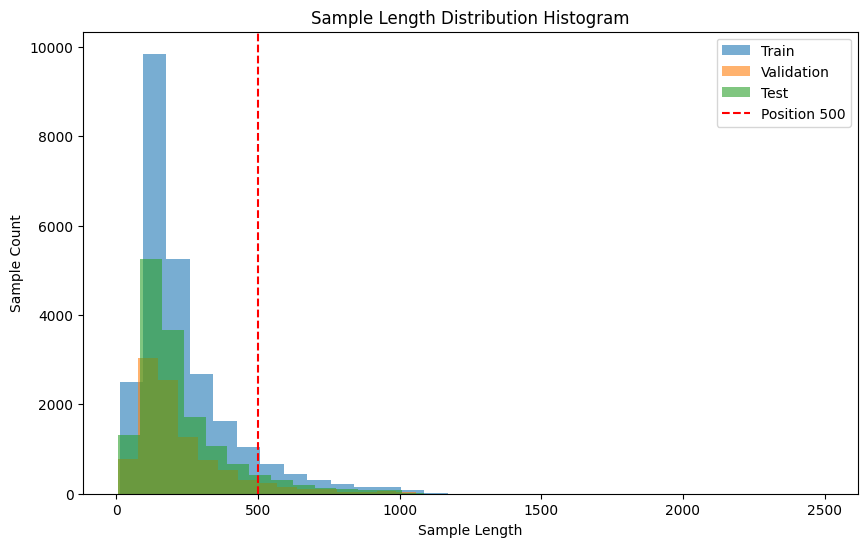

In [9]:
import matplotlib.pyplot as plt

# Calculate sample lengths
train_lengths = [len(seq) for seq in x_train]
val_lengths = [len(seq) for seq in x_val]
test_lengths = [len(seq) for seq in x_test]

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=30, alpha=0.6, label='Train')
plt.hist(val_lengths, bins=30, alpha=0.6, label='Validation')
plt.hist(test_lengths, bins=30, alpha=0.6, label='Test')
plt.axvline(x=500, color='r', linestyle='--', label='Position 500')
plt.xlabel('Sample Length')
plt.ylabel('Sample Count')
plt.title('Sample Length Distribution Histogram')
plt.legend()
plt.show()


# Tokenizer

In [10]:
from unittest import result

class Tokenizer:
    def __init__(self, word_index, index_to_word):
        """
        初始化Tokenizer对象，管理词与id的映射、特殊符号及词表大小信息。

        参数:
            word_index: dict, 词 --> id 映射，构成词典（如 {'hello':5, ...}）
            index_to_word: dict, id --> 词 映射，词典的逆映射（如 {5:'hello', ...}）
        """
        self.word_index = word_index                      # 词到id的映射字典
        self.index_to_word = index_to_word                # id到词的映射字典
        self.vocab_size = len(word_index)                 # 词表大小

        # 定义特殊标记，常用于序列任务处理（如填充、起止符、未知词等）
        # 参照embedding章节Notebooks设计，id分配如下：
        # "[PAD]": 0,  # 填充 token
        # "[BOS]": 1,  # 句子开始 token
        # "[UNK]": 2,  # 未知 token
        # "[EOS]": 3,  # 句子结束 token
        self.pad_token = "[PAD]"                          # 填充符
        self.bos_token = "[BOS]"                          # 句首符
        self.unk_token = "[UNK]"                          # 未知词符
        self.eos_token = "[EOS]"                          # 句尾符
        self.pad_id = self.word_index[self.pad_token]     # 填充符id
        self.bos_id = self.word_index[self.bos_token]     # 句首符id
        self.unk_id = self.word_index[self.unk_token]     # 未知词id
        self.eos_id = self.word_index[self.eos_token]     # 句尾符id

    def encode(self, text, maxlen=None, padding='post', truncating='post',
               add_bos=False, add_eos=False):
        """
        将一批token序列（列表）批量转为id序列，支持填充、截断、添加BOS/EOS等。

        参数:
            text: List[List[str]], 输入的token列表序列（批量，一条数据一行）
            maxlen: int 或 None，最终每条样本的最大长度；若为None则自动对齐本批最大长度
            padding: 'pre'或'post'，决定填充在序列前还是后
            truncating: 'pre'或'post'，超长时，保留前/后maxlen个
            add_bos: bool，是否在每个样本前加"[BOS]"
            add_eos: bool，是否在每个样本后加"[EOS]"
        返回:
            np.array, shape=(batch_size, maxlen)，每行都是id序列（已填充）
        """
        if not isinstance(text, list):
            raise ValueError("输入text应为字符串列表")
        
        # 计算本批数据的最长序列长度（若加上BOS/EOS则加1）
        batch_max_len = max([len(seq) for seq in text])   # 得到本批样本的最长长度
        if add_bos:
            batch_max_len += 1                            # 若要加BOS，占一位
        if add_eos:
            batch_max_len += 1                            # 若要加EOS，再占一位

        # 若无maxlen或maxlen大于本批最大长度，则用本批长度，否则按maxlen
        if maxlen is None or batch_max_len < maxlen:
            maxlen = batch_max_len                        # 目标长度
        
        result=[]                                         # 存放最终batch id序列
        for text_item in text:
            sequence = []

            # 添加句首符(BOS)
            if add_bos:
                sequence.append(self.bos_id)

            # 将每个词转换为id（词典中无的用UNK）
            for word in text_item:
                sequence.append(self.word_index.get(word, self.unk_id))

            # 添加句尾符(EOS)
            if add_eos:
                sequence.append(self.eos_id)

            # 若序列超长，按truncating方式进行截断
            if len(sequence) > maxlen:
                if truncating == 'pre':
                    sequence = sequence[-maxlen:]         # 截取后maxlen个
                else:  # truncating == 'post'
                    sequence = sequence[:maxlen]          # 截取前maxlen个
            else:
                # 序列不够长时，按padding方式补PAD id到maxlen
                pad_length = maxlen - len(sequence)
                if pad_length > 0:
                    if padding == 'pre':
                        sequence = [self.pad_id] * pad_length + sequence
                    else:  # padding == 'post'
                        sequence = sequence + [self.pad_id] * pad_length

            result.append(sequence)

        return np.array(result)

    def decode(self, ids, remove_special=True):
        """
        把二维id序列转回token字符串列表。
        支持移除特殊符号（[PAD]、[BOS]、[EOS]）。

        参数:
            ids: List[List[int]] 或 2D np.array，每一行是一个句子的id序列
            remove_special: bool，是否移除特殊符号（默认会去掉PAD,BOS,EOS）
        返回:
            List[str], 每个元素为一条字符串（tokens用空格拼接）
        """
        results = []
        special_tokens = {self.pad_token, self.bos_token, self.eos_token}  # 构建特殊符号集合
        for seq in ids:                  # 遍历每个样本（序列）
            tokens = []
            for idx in seq:              # 遍历当前序列所有id
                token = self.index_to_word.get(idx, self.unk_token)    # id转词
                if remove_special and token in special_tokens:         # 是否去特殊符号
                    continue
                tokens.append(token)
            results.append(' '.join(tokens))          # 把tokens组合成字符串

        return results


In [11]:
raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
raw_text

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

In [12]:
index_to_word[4825]

'hello'

In [13]:
tokenizer=Tokenizer(word_index,index_to_word)
encoded_text = tokenizer.encode(raw_text)
print(encoded_text)
decoded_text = tokenizer.decode(encoded_text)
print(decoded_text)


[[ 4825   182     0     0     0]
 [    2  3004     2    19 19233]
 [   14     9     6  2181     0]]
['hello world', '[UNK] text [UNK] with batch', 'this is a test']


# Dataset和DataLoader

In [14]:
a,b=zip(('a',1),('b',1),('c',0))
print(a)
print(b)


('a', 'b', 'c')
(1, 1, 0)


In [15]:
from torch.utils.data import Dataset, DataLoader
import torch
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        """
        参数:
            texts: 原始文本数据，列表形式，每个元素是一个句子的token列表
            labels: 标签数据，列表形式
        """
        self.texts = tokenizer.decode(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch,max_len=500):
    """
    DataLoader的collate_fn，对批次数据进行编码和填充
    参数:
        batch: 一个批次的原始文本数据和标签
    返回:
        编码后的tensor和标签tensor
    """
    texts, labels = zip(*batch)
    # 先将每个文本字符串split成token列表
    token_lists = [text.split() for text in texts]
    # 使用tokenizer对批次数据进行编码
    encoded_batch = tokenizer.encode(token_lists,maxlen=max_len,padding='pre', add_bos=False, add_eos=True)
    return torch.tensor(encoded_batch, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# 创建训练集DataLoader
train_dataset = TextDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

# 创建验证集DataLoader
val_dataset = TextDataset(x_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# 创建测试集DataLoader
test_dataset = TextDataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# 测试训练集DataLoader
print("Training DataLoader:")
for batch_texts, batch_labels in train_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    print("Batch content:")
    print(batch_texts)
    print("Batch labels:")
    print(batch_labels)
    print("Decoded batch:")
    decoded_batch = tokenizer.decode(batch_texts.tolist())
    print(decoded_batch)
    break  # 只显示第一个batch

print("-" * 50)
print("Validation DataLoader:")
for batch_texts, batch_labels in val_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch

print("-" * 50)
print("Test DataLoader:")
for batch_texts, batch_labels in test_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch


Training DataLoader:
Batch texts shape: torch.Size([64, 500])
Batch labels shape: torch.Size([64])
Batch content:
tensor([[   0,    0,    0,  ...,    7, 3265,    3],
        [   0,    0,    0,  ...,   87, 1107,    3],
        [   0,    0,    0,  ...,  140,  355,    3],
        ...,
        [   0,    0,    0,  ...,  119,  602,    3],
        [   0,    0,    0,  ...,   17, 1353,    3],
        [   0,    0,    0,  ...,    4, 8916,    3]])
Batch labels:
tensor([1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0])
Decoded batch:
["there are very few performers today who can keep me captivated throughout an entire film just by their presence one of those few is judy davis who has built a successful career out of creating characters that are [UNK] in attitude but very vulnerable at heart she takes roles that most other performers would tre

# 搭建分类模型

In [16]:
import torch
import torch.nn as nn

class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=1, bidirectional=False):
        """
        文本分类模型，基于Embedding和LSTM实现，可选多个RNN层和双向结构。

        Args:
            vocab_size (int): 词表大小
            embedding_dim (int): 词向量维度
            hidden_dim (int): LSTM隐层单元数
            num_classes (int): 输出类别数（如果是二分类，通常为1；多分类为类别数）
            rnn_layers (int): LSTM堆叠层数
            bidirectional (bool): 是否使用双向LSTM
        """
        super().__init__()
        # 词嵌入层，将输入的 token id 映射为稠密向量，pad 的 token id=0
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.bidirectional = bidirectional
        # LSTM层，batch_first=True 代表输入输出形状均以 batch 作为第一维
        self.rnn = nn.LSTM(
            input_size=embedding_dim,      # 词嵌入维度作为LSTM输入特征维度
            hidden_size=hidden_dim,        # LSTM隐状态（隐藏向量）维度
            num_layers=rnn_layers,         # LSTM层数（可叠加）
            batch_first=True,              # 输入输出的第0维为batch
            bidirectional=bidirectional    # 是否使用双向LSTM
        )
        # 如果是双向LSTM，输出维度要乘以2
        rnn_output_dim = hidden_dim * (2 if bidirectional else 1)
        # 第一个全连接层，用于降维或进一步特征混合
        self.fc1 = nn.Linear(rnn_output_dim, hidden_dim)
        self.relu = nn.ReLU()
        # 最终输出层到类别数量维度（如果是二分类输出1，多分类输出num_classes）
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """
        前向传播

        Args:
            x (LongTensor): shape (batch_size, seq_len), 输入为句子的token id序列

        Returns:
            out (Tensor): shape (batch_size, num_classes)
        """
        # 词嵌入：将token id序列映射为词向量 (batch, seq_len, embedding_dim)
        embed = self.embedding(x)
        # LSTM前向输出
        # output: 每个时间步的输出, shape (batch, seq_len, num_directions*hidden_dim)
        # h_n, c_n: 每层每个方向最后一个时间步的隐状态和细胞状态
        output, (h_n, c_n) = self.rnn(embed)
        # print("LSTM output shape:", output.shape)  # (batch, seq_len, hidden*directions)
        # print("LSTM h_n shape:", h_n.shape)        # (num_layers * directions, batch, hidden_dim)
        # print('LSTM c_n shape',c_n.shape)          # (num_layers * directions, batch, hidden_dim)
        # 获取最后一层最后一个时间步的hidden状态作为句子表征
        if self.bidirectional:
            # 对于双向LSTM，h_n最后一层包含forward和backward两个方向
            # h_n[-2,:,:]: forward最后一层
            # h_n[-1,:,:]: backward最后一层
            # 拼接两个方向的hidden（shape：(2, batch, hidden_dim)→(batch, hidden_dim*2)）
            last_layer_h_n = h_n[-2:,:,:]   # shape: (2, batch, hidden_dim)
            last_hidden = torch.cat([last_layer_h_n[0], last_layer_h_n[1]], dim=-1)  # (batch, hidden_dim*2)
        else:
            # 单向LSTM直接取最后一层hidden
            last_hidden = h_n[-1]  # (batch, hidden_dim)
        # 经过全连接+激活函数
        out = self.fc1(last_hidden)
        out = self.relu(out)
        out = self.fc2(out)  # (batch, num_classes)
        return out

# 设定模型参数举例
vocab_size = num_words              # 词表大小（应与tokenizer一致）
embedding_dim = 16                  # 词向量维度，可以根据数据量调整
hidden_dim = 64                     # LSTM隐藏单元数
num_classes = 1                     # 二分类问题应为1，softmax多分类用类别数
rnn_layers = 1                      # LSTM堆叠层数
bidirectional = False               # 是否启用双向LSTM

# 实例化模型
model = TextClassificationModel(
    vocab_size, embedding_dim, hidden_dim,
    num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional
)


In [17]:
# 编写前向计算验证模型
# 假设有一个 batch 输入张量（随机生成，并假设最大长度为 10）
batch_size = 2
seq_len = 10
x = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
print(x.shape)
with torch.no_grad():
    outputs = model(x)
    print("Output shape:", outputs.shape)
    print("Output:", outputs)


torch.Size([2, 10])
Output shape: torch.Size([2, 1])
Output: tensor([[ 0.0010],
        [-0.0276]])


In [18]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 4096
rnn.weight_hh_l0: 16384
rnn.bias_ih_l0: 256
rnn.bias_hh_l0: 256
fc1.weight: 4096
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 185217


In [19]:
4096*4

16384

# 训练

In [20]:
len(train_dataloader)

391

In [21]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
)

# 开始训练
trainer.train_binary(num_epochs=20)


[Step 100] Val Loss: 0.6770 Val Acc: 0.5720
[Step 200] Val Loss: 0.6464 Val Acc: 0.6237
[Step 300] Val Loss: 0.6703 Val Acc: 0.6057
Epoch [1/20] Train Loss: 0.6669 Acc: 0.5920 | Val Loss: 0.6703 Val Acc: 0.6057
[Step 400] Val Loss: 0.6264 Val Acc: 0.6602
[Step 500] Val Loss: 0.6196 Val Acc: 0.6599
[Step 600] Val Loss: 0.5951 Val Acc: 0.6999
[Step 700] Val Loss: 0.5597 Val Acc: 0.7143
Epoch [2/20] Train Loss: 0.5811 Acc: 0.6971 | Val Loss: 0.5597 Val Acc: 0.7143
[Step 800] Val Loss: 0.5541 Val Acc: 0.7205
[Step 900] Val Loss: 0.5185 Val Acc: 0.7498
[Step 1000] Val Loss: 0.5077 Val Acc: 0.7545
[Step 1100] Val Loss: 0.4769 Val Acc: 0.7766
Epoch [3/20] Train Loss: 0.5022 Acc: 0.7574 | Val Loss: 0.4769 Val Acc: 0.7766
[Step 1200] Val Loss: 0.4765 Val Acc: 0.7758
[Step 1300] Val Loss: 0.4472 Val Acc: 0.7902
[Step 1400] Val Loss: 0.4417 Val Acc: 0.7965
[Step 1500] Val Loss: 0.4244 Val Acc: 0.8054
Epoch [4/20] Train Loss: 0.4153 Acc: 0.8153 | Val Loss: 0.4244 Val Acc: 0.8054
[Step 1600] Val Lo

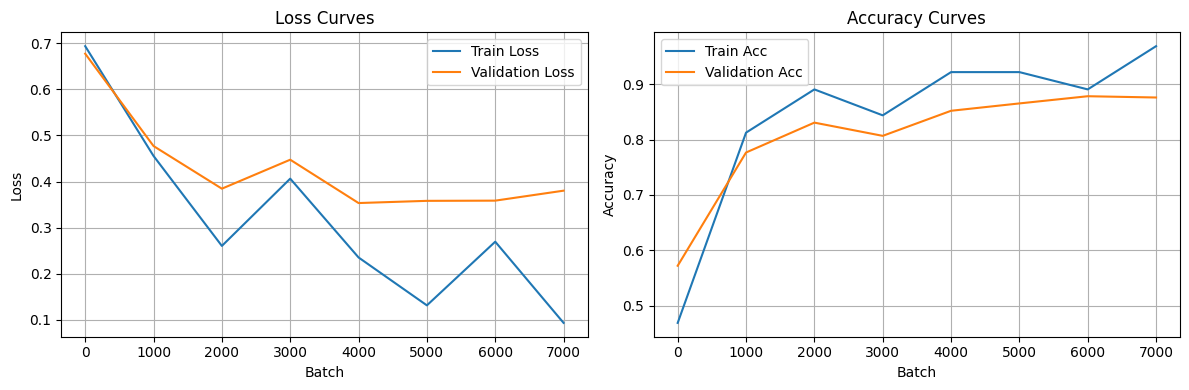

In [22]:
trainer.plot_curves()

# 单层双向LSTM

In [23]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 1
bidirectional = True

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)

[Step 100] Val Loss: 0.6884 Val Acc: 0.5443
[Step 200] Val Loss: 0.6612 Val Acc: 0.6065
[Step 300] Val Loss: 0.6299 Val Acc: 0.6582
Epoch [1/20] Train Loss: 0.6640 Acc: 0.5894 | Val Loss: 0.6299 Val Acc: 0.6582
[Step 400] Val Loss: 0.6364 Val Acc: 0.6438
[Step 500] Val Loss: 0.6242 Val Acc: 0.6673
[Step 600] Val Loss: 0.5954 Val Acc: 0.6890
[Step 700] Val Loss: 0.6374 Val Acc: 0.6751
Epoch [2/20] Train Loss: 0.5942 Acc: 0.6896 | Val Loss: 0.6374 Val Acc: 0.6751
[Step 800] Val Loss: 0.5569 Val Acc: 0.7159
[Step 900] Val Loss: 0.5306 Val Acc: 0.7419
[Step 1000] Val Loss: 0.5360 Val Acc: 0.7496
[Step 1100] Val Loss: 0.5095 Val Acc: 0.7563
Epoch [3/20] Train Loss: 0.4931 Acc: 0.7708 | Val Loss: 0.5095 Val Acc: 0.7563
[Step 1200] Val Loss: 0.4852 Val Acc: 0.7684
[Step 1300] Val Loss: 0.4696 Val Acc: 0.7806
[Step 1400] Val Loss: 0.4516 Val Acc: 0.7960
[Step 1500] Val Loss: 0.4752 Val Acc: 0.7772
Epoch [4/20] Train Loss: 0.4418 Acc: 0.7994 | Val Loss: 0.4752 Val Acc: 0.7772
[Step 1600] Val Lo

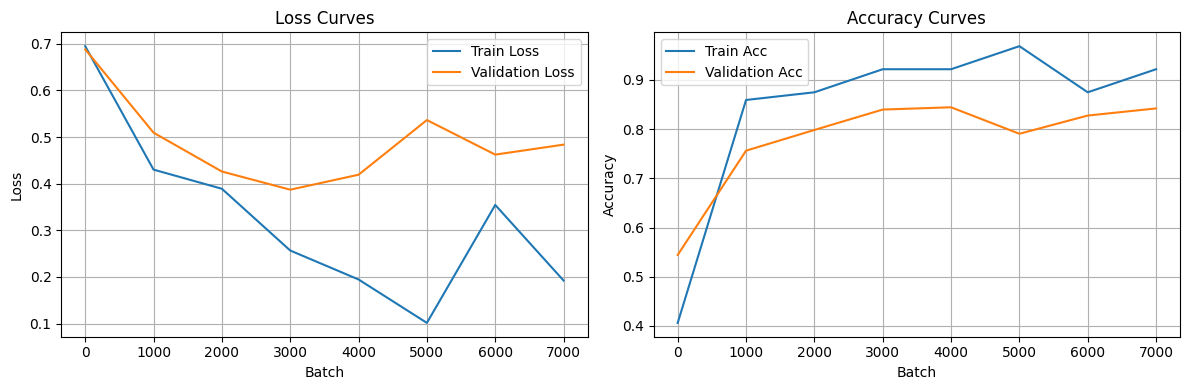

In [24]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
    early_stopping_kwargs=dict(patience=5, min_delta=1e-4, mode='max'),
)

# 开始训练
trainer.train_binary(num_epochs=20)
trainer.plot_curves()

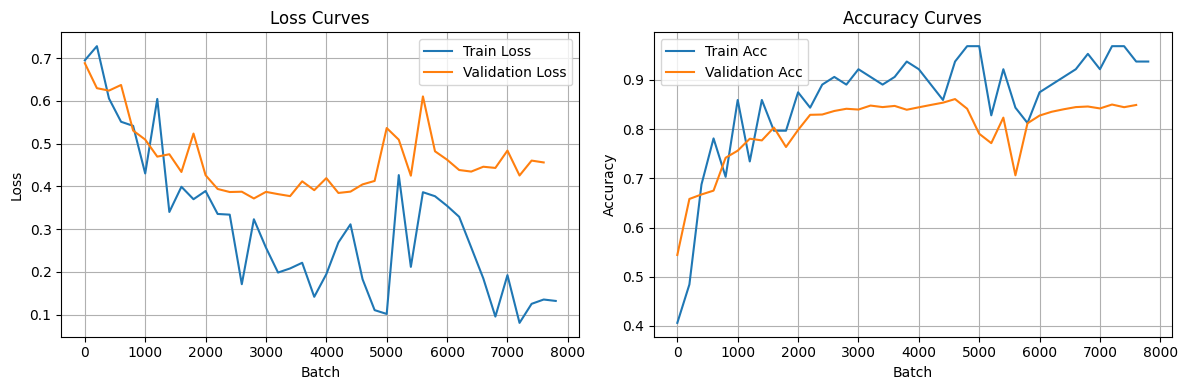

In [25]:
trainer.plot_curves(200)

# 双层单向 LSTM

In [27]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 2
bidirectional = False

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional).to(device)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 编写前向计算验证模型
# 随便生成一个 batch 的数据进行前向推理，可以用 DataLoader 中的一批
model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        break  # 只跑一批


In [28]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 4096
rnn.weight_hh_l0: 16384
rnn.bias_ih_l0: 256
rnn.bias_hh_l0: 256
rnn.weight_ih_l1: 16384
rnn.weight_hh_l1: 16384
rnn.bias_ih_l1: 256
rnn.bias_hh_l1: 256
fc1.weight: 4096
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 218497


[Step 100] Val Loss: 0.6920 Val Acc: 0.5209
[Step 200] Val Loss: 0.6757 Val Acc: 0.5728
[Step 300] Val Loss: 0.6407 Val Acc: 0.6317
Epoch [1/20] Train Loss: 0.6679 Acc: 0.5776 | Val Loss: 0.6407 Val Acc: 0.6317
[Step 400] Val Loss: 0.6178 Val Acc: 0.6617
[Step 500] Val Loss: 0.6279 Val Acc: 0.6523
[Step 600] Val Loss: 0.5629 Val Acc: 0.7166
[Step 700] Val Loss: 0.5357 Val Acc: 0.7380
Epoch [2/20] Train Loss: 0.5693 Acc: 0.7078 | Val Loss: 0.5357 Val Acc: 0.7380
[Step 800] Val Loss: 0.5324 Val Acc: 0.7369
[Step 900] Val Loss: 0.6194 Val Acc: 0.6388
[Step 1000] Val Loss: 0.5892 Val Acc: 0.6840
[Step 1100] Val Loss: 0.6492 Val Acc: 0.5795
Epoch [3/20] Train Loss: 0.5792 Acc: 0.6930 | Val Loss: 0.6492 Val Acc: 0.5795
[Step 1200] Val Loss: 0.5831 Val Acc: 0.6941
[Step 1300] Val Loss: 0.6953 Val Acc: 0.4974
[Step 1400] Val Loss: 0.6931 Val Acc: 0.4973
[Step 1500] Val Loss: 0.6928 Val Acc: 0.4973
Epoch [4/20] Train Loss: 0.6542 Acc: 0.5751 | Val Loss: 0.6928 Val Acc: 0.4973
[Step 1600] Val Lo

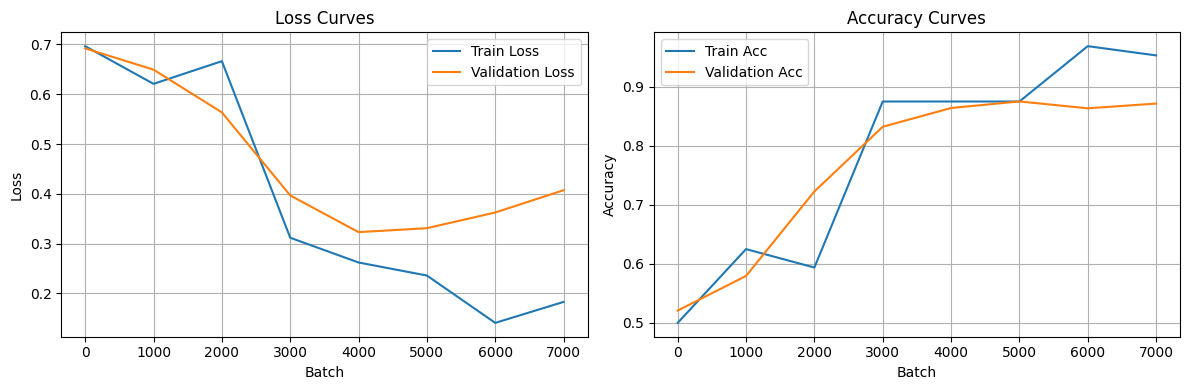

In [29]:
from torch import device
from wangdao_train import Trainer

# 定义损失函数和优化器
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# 假定 train_loader, val_loader, device 已经准备好
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 可调整
    early_stopping_kwargs=dict(patience=3, min_delta=1e-4, mode='max'),
)

# 开始训练
trainer.train_binary(num_epochs=20)
trainer.plot_curves()

# 双层双向LSTM

In [30]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 2
bidirectional = True

model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional).to(device)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 编写前向计算验证模型
# 随便生成一个 batch 的数据进行前向推理，可以用 DataLoader 中的一批
model.eval()
with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        break  # 只跑一批


In [31]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")

参数量统计：
embedding.weight: 160000
rnn.weight_ih_l0: 4096
rnn.weight_hh_l0: 16384
rnn.bias_ih_l0: 256
rnn.bias_hh_l0: 256
rnn.weight_ih_l0_reverse: 4096
rnn.weight_hh_l0_reverse: 16384
rnn.bias_ih_l0_reverse: 256
rnn.bias_hh_l0_reverse: 256
rnn.weight_ih_l1: 32768
rnn.weight_hh_l1: 16384
rnn.bias_ih_l1: 256
rnn.bias_hh_l1: 256
rnn.weight_ih_l1_reverse: 32768
rnn.weight_hh_l1_reverse: 16384
rnn.bias_ih_l1_reverse: 256
rnn.bias_hh_l1_reverse: 256
fc1.weight: 8192
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 309633


In [32]:
128*64

8192